In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster import hierarchy 
%matplotlib inline

- First-batch model: connectivity coefficient matrix across all cell types

Skipping PV8...
Skipping PV9...
Skipping PV10...
Skipping SST4...
Skipping SST5...
Skipping SST6...
Skipping SST7...
Skipping SST8...
Skipping SST9...
Skipping SST10...
Skipping VIP5...
Skipping VIP6...
Skipping VIP7...
Skipping VIP8...
Skipping VIP9...
Skipping VIP10...
Shape of celltypeCamkII_TST: (1516, 41)
Shape of celltypePV: (341, 41)
Shape of celltypeSST: (47, 41)
Shape of celltypeVIP: (297, 41)


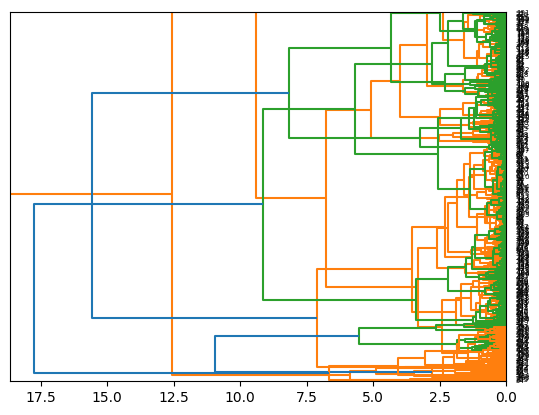

In [12]:
projectpath = r'g:\XJN_M2project'
test = 'test1'
event_type = 'S_to_I'#S_to_I,I_to_S
all_file_path = {}
out_path = os.path.join(projectpath, 'correlation_analysis', test)
if not os.path.exists(out_path):os.makedirs(out_path)


all_celltypes = ['CamkII_TST','PV','SST','VIP']#'CamkII_TST', 'SST', 'PV', 'VIP'
subjects = np.arange(1, 11)  # Assume each cell type has 10 subjects (consistent with CamkII)

for i,celltype in enumerate(all_celltypes):
    all_file_path[celltype] = []
    for subject in subjects:
        subject_dir = os.path.join(projectpath, 'summary', test, celltype, str(subject))
        if os.path.exists(subject_dir):
            file_path = os.path.join(subject_dir,'signal_save', f'{event_type}_event_average_zscore_denoised.csv')
            if os.path.isfile(file_path):
                all_file_path[celltype].append(file_path)
            else:
                raise FileNotFoundError(f"File does not exist: {file_path}")
        else:
            print(f"Skipping {celltype}{subject}...")#Mouse not available




all_celltype_df = []
for i,celltype in enumerate(all_file_path.keys()):
    celltype_df = []
    for file in all_file_path[celltype]:
        subject_df = pd.read_csv(file)
        if  subject_df.shape[1] > 400:
            raise ValueError(f"DataFrame has more than 400 frames: {file}")
        subject_df = subject_df.drop(columns='Unnamed: 0')
        if subject_df.isna().any().any():
            raise ValueError(f'DataFrame has nan values: {file}')
        subject_df.insert(loc=0, column='celltype', value=i + 1)
        celltype_df.append(subject_df)
    
    celltype_df = pd.concat(celltype_df,axis=0)
    ######
    # Within-group clustering
    ########
    row_linkage = hierarchy.linkage(
    celltype_df,                # Input data (rows = samples to cluster)
    method='ward',     # Clustering method (e.g., 'ward', 'complete', 'average')
    metric='euclidean' # Distance metric (e.g., 'euclidean', 'correlation')
)
    hierarchy.dendrogram(row_linkage,orientation='left')
    row_order = hierarchy.leaves_list(row_linkage)
    # plt.show()
    # plt.close()
    celltype_df = celltype_df.iloc[row_order,:]
    temp = celltype_df.to_numpy()
    print(f'Shape of celltype{celltype}: {temp.shape}')

    
    all_celltype_df.append(celltype_df)




In [13]:
temp

array([[ 4.        , -0.04166524, -0.05045285, ...,  1.82438258,
         1.85968803,  2.00313401],
       [ 4.        ,  0.11048708,  0.08154688, ...,  0.75609634,
         0.75591391,  0.73350023],
       [ 4.        , -0.13630263, -0.11619377, ...,  1.09301709,
         1.03936803,  0.99835616],
       ...,
       [ 4.        , -0.03445346, -0.03458552, ..., -0.29263027,
        -0.3075149 , -0.32273774],
       [ 4.        , -0.27781995, -0.30492117, ..., -0.27997473,
        -0.29094328, -0.30748422],
       [ 4.        , -0.35301345, -0.31358237, ..., -0.55681282,
        -0.56896765, -0.58657779]])

Maxtime is 41


Text(0.5, 1.0, 'Combined Cell Types Event Average Z-score Denoised')

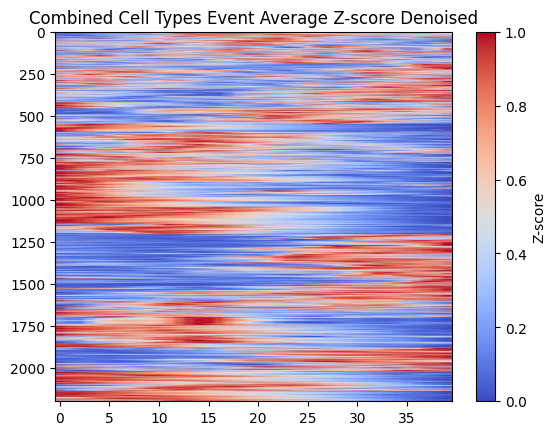

In [14]:
maxtime = min(df.shape[1] for df in all_celltype_df)
print(f'Maxtime is {maxtime}')
all_celltype_df = [df.iloc[:,:maxtime] for df in all_celltype_df]
combined_df = pd.concat(all_celltype_df,axis=0)
temp = combined_df.copy()
scaler = MinMaxScaler()
temp.iloc[:,1:] = scaler.fit_transform(temp.iloc[:,1:].T).T
plt.imshow(temp.iloc[:,1:].to_numpy(), aspect='auto', cmap='coolwarm')
plt.colorbar(label='Z-score')
plt.title('Combined Cell Types Event Average Z-score Denoised')

correlation size(2201, 2201)
Before: max1.0,min:-0.9949780819558591


Text(0.5, 0, 'Correlation Coefficient')

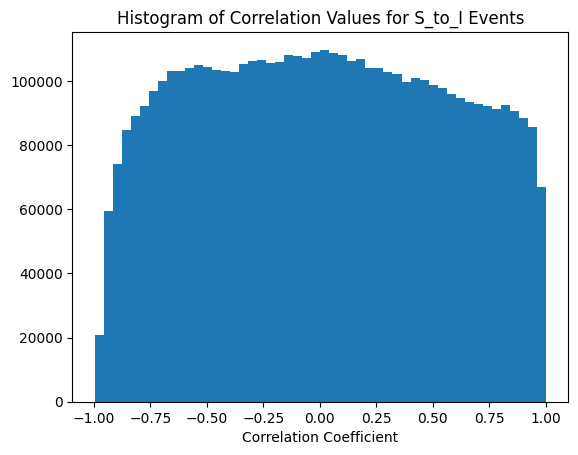

In [15]:
correlation_matrix = np.corrcoef(combined_df.drop(columns='celltype'))
print(f'correlation size{correlation_matrix.shape}')
corr_flat = correlation_matrix.flatten()
print(f'Before: max{max(corr_flat)},min:{min(corr_flat)}')

plt.hist(corr_flat, bins=50)
plt.title(f'Histogram of Correlation Values for {event_type} Events')
plt.xlabel('Correlation Coefficient')

# Step 2: Calculate mean and standard deviation of the correlation values
# mean_corr = np.mean(corr_flat)
# std_corr = np.std(corr_flat, ddof=1) 
# correlation_matrix = (correlation_matrix-mean_corr)/std_corr
# corr_flat = correlation_matrix.flatten()
# print(f'After: max{max(corr_flat)},min:{min(corr_flat)}')

# Threshold clipping
# max_median = correlation_matrix.max(axis=1).median()
# min_median = correlation_matrix.min(axis=1).median()
# min_min = correlation_matrix.min(axis=1).min()
# max_max = correlation_matrix.max(axis=1).max()




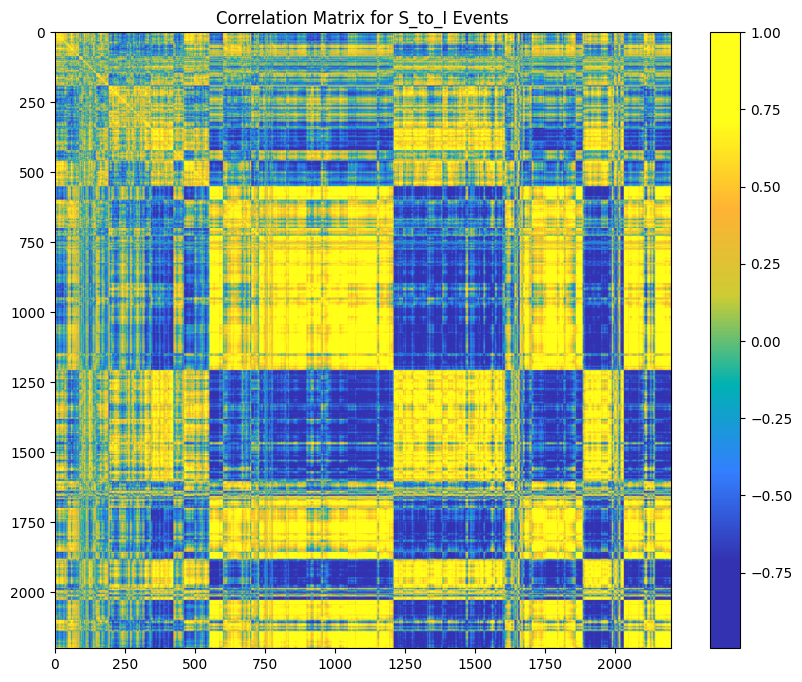

In [16]:
# Heatmap colorbar
index = np.linspace(0, 1, 8)
colors = [(0,'#3333b2'),
            (index[1],'#3333b2'),
            (index[2],'#337fff'),
            (index[3],'#00b2b2'),
            (index[4],'#cccc33'),
            (index[5],'#ffb233'),
            (index[6],'#ffff19'),
            (1,'#ffff19')]
cmap = LinearSegmentedColormap.from_list('custom_colormap',colors)

# Clustering coefficient matrix
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap=cmap)
plt.colorbar()
plt.title(f'Correlation Matrix for {event_type} Events')
plt.savefig(os.path.join(out_path, f'{event_type}_correlation_matrix.pdf'))
plt.show()

Celltype 1: CamkII_TST, count: 1516
Celltype 2: PV, count: 341
Celltype 3: SST, count: 47
Celltype 4: VIP, count: 297


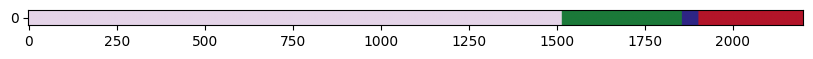

In [17]:
# Cell ordering bar
cmap = mpl.colors.ListedColormap(['#E5D4E8','#1B7939','#2E2585','#B31529'])
plt.figure(figsize=(10, 0.2))
plt.yticks(np.arange(0,combined_df.shape[0], step=100))
celltype_array = combined_df['celltype'].to_numpy().reshape(1,-1)
plt.imshow(celltype_array, cmap=cmap, aspect='auto')
plt.savefig(os.path.join(out_path,f'{event_type}_celltype_bar.pdf'))

for i,celltype in enumerate(all_celltypes):
    print(f'Celltype {i+1}: {celltype}, count: {np.sum(combined_df["celltype"] == (i + 1))}')

0.1956345682032408


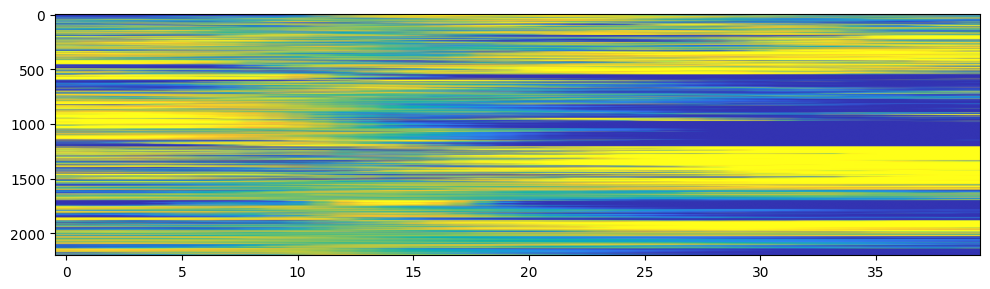

c:\ProgramData\miniconda3\envs\conda_global\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


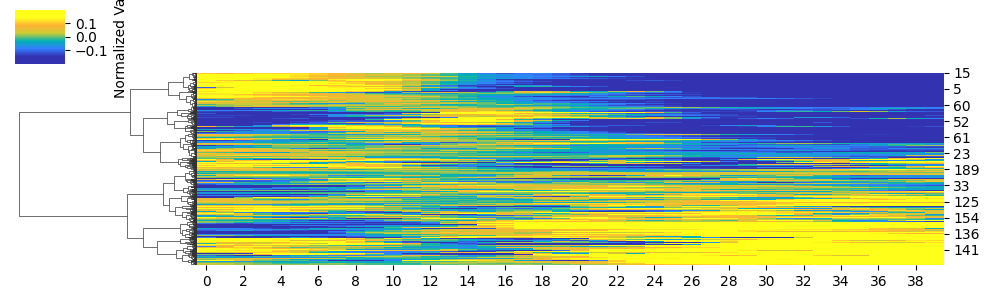

In [18]:
# 40-frame event transition map (all cell types)
if 'celltype' in combined_df.columns:
    combined_temp = combined_df.drop(columns='celltype')

max_max = combined_temp.max(axis=1).max()
min_min = combined_temp.min(axis=1).min()
max_median = combined_temp.max(axis=1).median()
min_median = combined_temp.min(axis=1).median()
cliped_df = combined_temp.clip(lower=min_median, upper=max_median)
print(cliped_df.max(axis=1).max())
#cliped_df = (cliped_df-min_median)/(max_median-min_median)

cmap = LinearSegmentedColormap.from_list('custom_colormap',colors)
fig, ax = plt.subplots(figsize=(10, 3))
cax = ax.imshow(cliped_df,cmap=cmap,aspect='auto')
#plt.savefig(os.path.join(out_path,f'{event_type}_combined_4s_heatmap.pdf'))    

plt.tight_layout()
plt.show()

g = sns.clustermap(cliped_df,
                    method='ward',
                    metric='euclidean',
                    cmap=cmap,
                    col_cluster=False,
                    row_cluster=True,  
                    figsize=(10, 3), 
                    cbar_kws={'label': 'Normalized Value'},
                    )
#plt.savefig(os.path.join(out_path,f'{event_type}_combined_4s_heatmap_clustered.pdf'))     

plt.show()           
plt.close()

In [19]:
# Save & preview data
correlation_df = pd.DataFrame(correlation_matrix,columns=combined_df.index,index=combined_df.index)
correlation_df = pd.concat([correlation_df,combined_df['celltype']],axis=1)
correlation_df.to_csv(os.path.join(out_path,f'{event_type}_correlation_matrix.csv'))
combined_df

,celltype,0,1,2,3,4,5,6,7,8,...,30,31,32,33,34,35,36,37,38,39
103,1,-0.995894,-0.996253,-0.996581,-0.996880,-0.997153,-0.997402,-0.997629,-0.997837,-0.998026,...,-0.232600,-0.299749,-0.361023,-0.416935,-0.467955,-0.514510,-0.556991,-0.595756,-0.631128,-0.663405
96,1,-0.276081,-0.345884,-0.408956,-0.465946,-0.517441,-0.563971,-0.606014,-0.644003,-0.678329,...,-0.404659,-0.462064,-0.377312,-0.307485,-0.374260,-0.434596,-0.489113,-0.538375,-0.582886,-0.623105
77,1,-0.576485,-0.562781,-0.551157,-0.549519,-0.536628,-0.550721,-0.586232,-0.615360,-0.626346,...,-0.438873,-0.476889,-0.504561,-0.522387,-0.536811,-0.554298,-0.574994,-0.591105,-0.603874,-0.611749
88,1,-0.077680,-0.165419,-0.122821,-0.156019,-0.194864,-0.227421,-0.260771,-0.310309,-0.375918,...,0.030526,0.012747,0.010483,0.000967,-0.003921,-0.026807,-0.004866,0.085340,0.129386,0.091381
97,1,-0.088983,-0.059865,-0.098322,-0.148352,-0.195607,-0.240239,-0.265484,-0.273663,-0.305897,...,0.154386,0.141690,0.131698,0.109000,0.067774,0.020314,-0.027373,-0.069914,-0.107889,-0.141407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,4,0.016734,-0.012517,-0.018973,-0.021367,-0.030590,-0.024855,0.022638,0.017738,-0.004699,...,-0.201750,-0.227567,-0.242750,-0.247799,-0.269217,-0.290977,-0.306283,-0.324508,-0.345219,-0.363467
29,4,0.003303,-0.009950,-0.022119,-0.037965,-0.056173,-0.050027,-0.034612,-0.042234,-0.039552,...,-0.213214,-0.228106,-0.224884,-0.233446,-0.247954,-0.262188,-0.267714,-0.277666,-0.291338,-0.299504
28,4,-0.034453,-0.034586,-0.034560,-0.049579,-0.067538,-0.078674,-0.059512,-0.044165,-0.049568,...,-0.177673,-0.196742,-0.212033,-0.230110,-0.247111,-0.257352,-0.275367,-0.292630,-0.307515,-0.322738
27,4,-0.277820,-0.304921,-0.306186,-0.310346,-0.338714,-0.341917,-0.316843,-0.255104,-0.158965,...,-0.291897,-0.306069,-0.261641,-0.223381,-0.213249,-0.229385,-0.255440,-0.279975,-0.290943,-0.307484
